# Transformation Simulation: Lognormal and exponential Dsitributions
## Objective
Demonstrate how to generate random variables using **transformation methods** and verify correctness by comparing **empirical CDF VS theoritical CDF**.

## Key Transformations
### 1. lognormal Distribution
If $Z \sim \mathcal{N}(\mu, \sigma^2) $, then:
$$ X=e^Z \sim \text{lognormal}(\mu, \sigma^2) $$

### 2. Exponential Distribution (Inverse Transform Method(very important in case we wanna build a sample based on a specific distribution we want))
If $ U \sim \text{Uniform}(0,1) $ and $F$ is a CDF with inverse $F^{-1}$, then:
$$ X= F^{-1}(U) \sim F$$

For Exponential with rate $\lambda$:
- CDF: $F(x)= 1-e^{-\lambda x} $
- Inverse: $F^{-1}(u) = -\frac{\ln(1-u)}{\lambda} $
- Since $1-U \stackrel{d}{=} U$, we use: $X = -\frac{\ln(U)}{\lambda}$

## Verification Approach
Compare the **empirical CDF** $\hat{F}_n(x)= \frac{1}{n}\sum_{i=1}^n \mathbf{1}_{X_i \leq x}$ against the **theoritical CDF**

In [4]:
!pip install scipy

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

os.makedirs('reports/figures', exist_ok= True)

np.random.seed(42)
N_samples = 10_000
print("Setup Complete")

Setup Complete


## PART 1: lognormal Distribution via Transformation

### Theory
The **Lognormal distribution** arises when we exponentiate a normally distributed variable:
$$Z \sim \mathcal{N}(\mu, \sigma^2) \implies X = e^Z \sim \text{Lognormal}(\mu, \sigma^2)$$

### Properties
- **Support**: $X>0$ (always positive)
- **Mean**: $E[X] = e^{\mu +\sigma^2/2}$
- **Variance**: $\text{Var}(X) = (e^{\sigma^2}-1) e^{2\mu +\sigma^2} $

### APPLICATIONS
- Stock prices( geometric Brownian motion)
- Particle sizes

In our simulation, we'll use $\mu = 0$ and $\sigma=1$, giving us the **standard lognormal** distribution

In [7]:
# parameters for log normal
mu = 0.0 # mean of underlying normal
sigma = 1.0 # std deviation of underlying normal

Z = np.random.normal(loc=mu, scale=sigma, size= N_samples)
# X = e^Z
X_lognormal = np.exp(Z)

theoretical_mean = np.exp(mu +sigma**2/2)
theoretical_var = (np.exp(sigma**2)-1)*np.exp(2*mu+sigma**2)

print("LOGNORMAL SIMULATION RESULTS")
print("="*50)
print(f"Parameters: mu= {mu}, sigma = {sigma}")
print()
print(f"Empirical Mean : {np.mean(X_lognormal):.4f}")
print(f"Theoretical Mean : {theoretical_mean:.4f}")
print()
print(f"Empirical Var: {np.var(X_lognormal, ddof=1): .4f}")
print(f"Theoretical Var: {theoretical_var:.4f}")
print()
print(f"Min: {X_lognormal.min():.4f}, Max: {X_lognormal.max():.4f}")


LOGNORMAL SIMULATION RESULTS
Parameters: mu= 0.0, sigma = 1.0

Empirical Mean : 1.6760
Theoretical Mean : 1.6487

Empirical Var:  5.3501
Theoretical Var: 4.6708

Min: 0.0211, Max: 88.1539


## Part 2: Exponential Distribution via Inverse Transform
### The inverse Transform Method
A fundamental technique for generating random variables:
> **Theorem**: If $U \sim \text{Unifrom}(0,1)$ and $F$ is a continuous CDF, then $X=^{-1}(U)$ has CDF $F$

### Applying to Exponential Distribution
For $X \sim \text{Exponential}(\lambda)$:
1. **CDF**: $F(x)= 1-e^{-\lambda x} $ for $x \geq 0$

2. **Find Inverse**: set $u = 1-e^{-\lambda x}$ and solve for $x$:
 $$x = -\frac{\ln(1-u)}{\lambda} $$

3. **Simplification** : Since $U \sim \text{Uniform}(0,1)$ implies  $1-U \sim \text{Uniform}(0,1) $:
 $$X = -\frac{\ln(U)}{\lambda} \sim \text{Exponential}(\lambda)$$

### Properties
- **Mean**: $E[X] = 1/\lambda$
- **Variance**: $\text{Var}(X) = 1/\lambda^2$
- **Memoryless**: $P(X>s+t|X>s) = P(X>t)$

In our siumlation, we'll use $\lambda=1.5$, giving mean $=1/1.5 $

In [9]:
lambda_param = 1.5
U = np.random.uniform(0,1,size=N_samples)

X_exponential = -np.log(U)/lambda_param

theoretical_mean_exp = 1/lambda_param
theoretical_var_exp = 1/lambda_param**2

print("EXPONENTIAL SIMULATION RESULTS")
print("="*50)
print(f"Parameter: lambda= {lambda_param}")
print()
print(f"Empirical Mean:{np.mean(X_exponential):.4f}")
print(f"Theoretical Mean: {theoretical_mean_exp:.4f}")
print()
print(f"Empirical Var:{np.var(X_exponential):.4f}")
print(f"theoretical Var:{theoretical_var_exp:.4f}")
print()
print(f"Min: {X_exponential.min():.4f}, Max: {X_exponential.max():.4f}")

EXPONENTIAL SIMULATION RESULTS
Parameter: lambda= 1.5

Empirical Mean:0.6713
Theoretical Mean: 0.6667

Empirical Var:0.4389
theoretical Var:0.4444

Min: 0.0001, Max: 8.0694


## Empirical CDF: 
The **Empirical Cumulative Distribution Function** is a step function that estimates true CDF from sample data:
$$\hat{F}_n(x)= \frac{1}{n} \sum_{i=1}^{n} \mathbf{1}_{X_i \leq x} = \frac{\text{nbr of samples} \leq x}{n}$$

### Properties
- $\hat{F}_n(x) \in [0,1]$
- Non Decreasing step function
- Jumps of size $1/n$ at each observation

### Convergence
By the **Glivenko-Cantelli theorem**:
$$\sup_x |\hat{F}_n(x) - F(x)| \xrightarrow{a.s.} 0 \text{ as } n \to \infty $$
This means the empirical CDF converges uniformly to the true CDF

### Our Approach
1. sort the samples
2. Assign cumulative probability $(i)/(n)$ to the $i$-th sorted value
3. Plot against theorical CDF to verify correctness



In [11]:
def empirical_cdf(samples):
    x_sorted = np.sort(samples)
    n = len(x_sorted)
    ecdf_values = np.arange(1,n+1)/n
    return x_sorted, ecdf_values
X_test, ecdf_test = empirical_cdf([3,1,4,5])
print(f"Sorted x: {X_test}")
print(f"ECDF values: {ecdf_test}")

Sorted x: [1 3 4 5]
ECDF values: [0.25 0.5  0.75 1.  ]


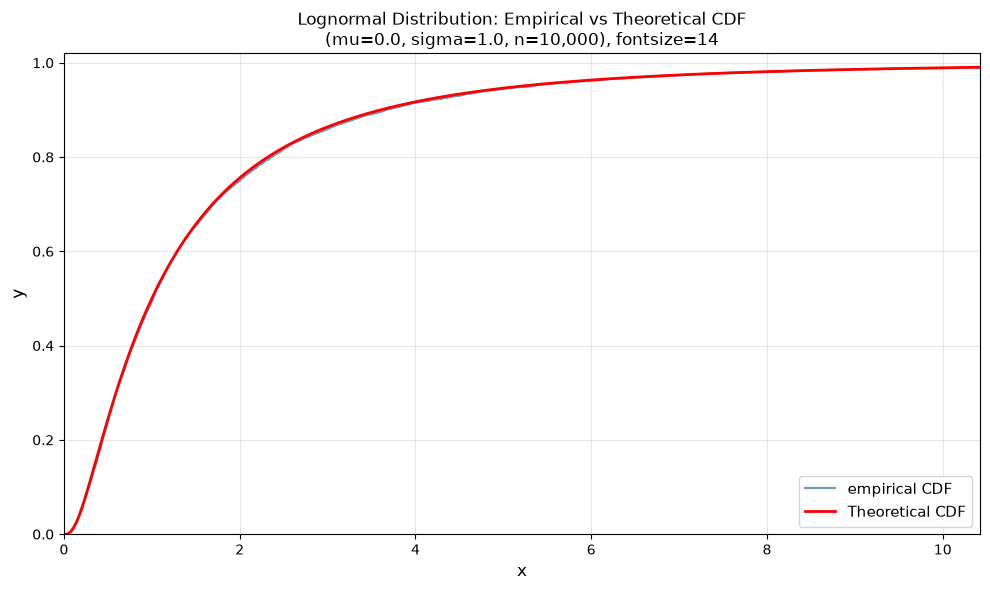

Figured saved!


In [13]:
""" Comparing Empirical vs Theoritical CDF for Lognormal Distribution"""

x_ln, ecdf_ln = empirical_cdf(X_lognormal)
# compute theoretical CDF
x_theory = np.linspace(0.001, np.percentile(X_lognormal, 99), 1000)
theoretical_cdf_ln = stats.lognorm.cdf(x_theory, s=sigma, scale=np.exp(mu))
# create figure
fig, ax =plt.subplots(figsize=(10,6))

# plot empirical CDF 
ax.step(x_ln, ecdf_ln, where='post', linewidth=1.5,
        color ='steelblue', alpha=0.8, label='empirical CDF')

# plot theoritical CDF
ax.plot(x_theory, theoretical_cdf_ln, 'r-', linewidth=2, label='Theoretical CDF')

#Formatting
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title(f"Lognormal Distribution: Empirical vs Theoretical CDF\n(mu={mu}, sigma={sigma}, n={N_samples:,}), fontsize=14")
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, np.percentile(X_lognormal, 99))
ax.set_ylim(0,1.02)

plt.tight_layout()
plt.savefig("reports/figures/lognormal_cdf_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("Figured saved!")


## Interpretation: Lognormal CDF Comparison
### Observations